# AFL Player Performance Investigation

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../../merged_players.csv")
print(f"Dataset shape: {df.shape}")
print(f"Seasons: {df['year'].min()} to {df['year'].max()}")
print(f"Teams: {df['team'].nunique()}")
print(f"Players: {df['player_id'].nunique()}")

Dataset shape: (25477, 69)
Seasons: 1983 to 2025
Teams: 20
Players: 3108


## Data Preparation
Filter to 2022–2024 regular season and aggregate per player across those seasons.

In [25]:
# regular season only, last 3 full seasons
recent = df[(df['year'].between(2022, 2024)) & (df['is_finals'] == False)].copy()
print("Rows in scope:", len(recent))

# aggregate per player across 3 seasons
player = recent.groupby(['player_id', 'player_name']).agg(
    seasons=('year', 'nunique'),
    total_games=('games_played', 'sum'),
    avg_disposals=('avg_disposals', 'mean'),
    avg_goals=('avg_goals', 'mean'),
    avg_marks=('avg_marks', 'mean'),
    avg_tackles=('avg_tackles', 'mean'),
    avg_clearances=('avg_clearances', 'mean'),
    avg_inside_50s=('avg_inside_50s', 'mean'),
    avg_fantasy_points=('avg_fantasy_points', 'mean'),
    avg_contested_possessions=('avg_contested_possessions', 'mean'),
    avg_goal_assists=('avg_goal_assists', 'mean'),
    avg_one_percenters=('avg_one_percenters', 'mean'),
    avg_kicks=('avg_kicks', 'mean'),
    brownlow_votes=('brownlow_votes', 'sum'),
    team=('team', 'last')
).reset_index()

# minimum 2 seasons and 10 games to filter fringe/injury-affected players
player = player[(player['seasons'] >= 2) & (player['total_games'] >= 10)].copy()
print(f"Players after quality filter: {len(player)}")

player.head()


Rows in scope: 2038
Players after quality filter: 612


,player_id,player_name,seasons,total_games,avg_disposals,avg_goals,avg_marks,avg_tackles,avg_clearances,avg_inside_50s,avg_fantasy_points,avg_contested_possessions,avg_goal_assists,avg_one_percenters,avg_kicks,brownlow_votes,team
0,43266,Blake Acres,3,62,22.333333,0.600000,5.766667,2.766667,2.066667,3.600000,87.233333,7.033333,0.700000,1.600000,13.266667,10.0,Carlton Blues
2,43269,Taylor Adams,3,58,19.466667,0.600000,3.066667,4.433333,3.833333,3.533333,75.166667,8.700000,0.966667,1.100000,9.766667,7.0,Sydney Swans
3,43273,Ben Ainsworth,3,60,16.433333,1.133333,5.166667,1.966667,1.066667,3.100000,71.733333,4.966667,1.100000,0.966667,10.600000,1.0,Gold Coast Suns
5,43275,James Aish,3,61,19.400000,0.200000,4.633333,2.333333,1.900000,3.266667,72.466667,5.200000,0.833333,1.200000,11.000000,3.0,Fremantle Dockers
6,43276,Leek Aleer,2,12,9.900000,0.000000,4.250000,2.450000,0.500000,1.000000,46.050000,4.300000,0.000000,5.150000,5.850000,0.0,Greater Western Sydney Giants


## Task 5 - Feature Engineering

1. disposal efficiency 

2. scoring impact

3. tackle presssure index

4. fantasy points per game

5. work rate


In [26]:
# # Feature 1: Disposal Efficiency
# Kicks are harder to execute than handballs but count as better ball use.
# Ratio of kicks to total disposals measures how cleanly a player moves the ball.
player['disposal_efficiency'] = (
    player['avg_kicks'] / player['avg_disposals'].replace(0, np.nan)
).round(3)

# Feature 2: Scoring Impact
# Goals are 6 points, goal assists directly create goals.
# Weighted combination captures a player's total offensive threat.
player['scoring_impact'] = (
    player['avg_goals'].fillna(0) + player['avg_goal_assists'].fillna(0) * 0.5
).round(3)

# Feature 3: Tackle Pressure Index
# Tackles are direct stoppages; one-percenters (spoils, smothers, shepards)
# are defensive pressure acts. Combined they measure defensive work rate.
player['tackle_pressure_index'] = (
    player['avg_tackles'].fillna(0) + player['avg_one_percenters'].fillna(0) * 0.5
).round(3)

# Feature 4: Fantasy Points per Game
# AFL fantasy scoring aggregates disposals, marks, tackles, goals and
# hitouts into a single composite score. Already a per-game average
# from the source but renamed for clarity.
player['fantasy_per_game'] = player['avg_fantasy_points'].round(2)

# Feature 5: Work Rate
# Sum of three core volume stats (disposals, marks, tackles) per game.
# Captures how much total involvement a player has in every match.
player['work_rate'] = (
    player['avg_disposals'].fillna(0) +
    player['avg_tackles'].fillna(0) +
    player['avg_marks'].fillna(0)
).round(2)

print("Features created. Sample:")
print(player[['player_name', 'disposal_efficiency', 'scoring_impact',
              'tackle_pressure_index', 'fantasy_per_game', 'work_rate']].head(10))


Features created. Sample:
      player_name  disposal_efficiency  scoring_impact  tackle_pressure_index  \
0     Blake Acres                0.594           0.950                  3.567   
2    Taylor Adams                0.502           1.083                  4.983   
3   Ben Ainsworth                0.645           1.683                  2.450   
5      James Aish                0.567           0.617                  2.933   
6      Leek Aleer                0.591           0.000                  5.025   
7     Aliir Aliir                0.732           0.167                  4.700   
8     Oscar Allen                0.732           2.725                  2.550   
9    Joel Amartey                0.695           1.817                  2.917   
10      Karl Amon                0.698           1.117                  3.233   
11      Jye Amiss                0.733           2.400                  1.633   

    fantasy_per_game  work_rate  
0              87.23      30.87  
2             

## why these 5 features 

**disposal efficicency:** Raw disposal count rewards volume; efficiency rewards quality. A player with 28 disposals and 70% kicks is more valuable than one with 30 disposals and 45% kicks.

**scoring_impact:**  Goals alone miss players who set up others. A midfielder who kicks 1 goal and 4 goal assists per game is more offensively valuable than their goal count suggests.

**tackle pressure index:** Tackles and one-percenters both create turnovers and pressure. Combining them gives a fuller picture of a player's defensive contribution

**fantasy_per_game:** AFL fantasy scoring is a well-validated composite metric — it's been tuned over years to reward meaningful game actions. Useful as a sanity check against custom indexes.

**work rate:** High work rate players tend to be more durable, high impact players, It identifies "engine room" players who influence games across all three phases. 




## Task 1 - Top 10 most valuable players 

### Performance Index Desgin

The index is built from 5 components, eac min-max normalised to 0-1 then weighted to a 100 point scale 


In [27]:
def minmax(s):
    mn,mx = s.min(), s.max()
    return (s - mn)/(mx - mn) if mx > mn else pd.Series(0.5, index=s.index)

player['score_disposals']  = minmax(player['avg_disposals'])  * 25   # 25%
player['score_fantasy']   = minmax(player['avg_fantasy_points']) * 30 # 30%
player['score_tackles']   = minmax(player['avg_tackles'])     * 15   # 15%
player['score_clearances'] = minmax(player['avg_clearances'].fillna(0)) * 15 # 15%
player['score_scoring']    = minmax(player['scoring_impact'])  * 15   # 15%


player['performance_index'] = (
    player['score_disposals'] + player['score_fantasy'] + player['score_tackles'] + player['score_clearances'] + 
    player['score_scoring'] ).round(2)

top10 = player.nlargest(10, 'performance_index').reset_index(drop=True)
top10[['player_name', 'team', 'total_games', 'avg_disposals',
       'avg_goals', 'avg_tackles', 'avg_fantasy_points', 'performance_index']]

    

,player_name,team,total_games,avg_disposals,avg_goals,avg_tackles,avg_fantasy_points,performance_index
0,Rory Laird,Adelaide Crows,65,29.866667,0.500000,7.266667,109.633333,85.03
1,Marcus Bontempelli,Western Bulldogs,67,25.666667,1.233333,6.033333,108.300000,82.15
2,Lachie Neale,Brisbane Lions,67,29.000000,0.733333,4.166667,101.700000,78.70
3,Patrick Cripps,Carlton Blues,65,27.433333,0.866667,5.300000,96.766667,78.28
4,Andrew Brayshaw,Fremantle Dockers,68,29.133333,0.666667,5.866667,109.100000,78.19
5,Clayton Oliver,Melbourne Demons,55,29.066667,0.533333,5.100000,101.266667,77.63
6,Zach Merrett,Essendon Bombers,64,29.033333,0.666667,4.933333,109.600000,77.29
7,Jack Steele,St Kilda Saints,61,24.800000,0.700000,7.300000,105.066667,76.98
8,Caleb Serong,Fremantle Dockers,65,28.600000,0.600000,4.766667,99.933333,76.70
9,Adam Treloar,Western Bulldogs,62,29.366667,0.933333,4.400000,103.900000,75.36


## Why these weights? 

**Fantasy Points** - 30% Best single composite of overall game impact - rewards disposals, marks, goals, tackles, hitouts in one validated metric

**Disposals** 25% The most consistent predictor of midfield dominance and ball-winning ability

**Tackles** 15% Contested defensive pressure so increasingly valued in modern AFL 

**Clearances** 15% Centre bounce and stoppage dominance directly leads to scoring opportunities

**Scoring Impact** 15% Direct offensive output (goals + assists) separates elite forwards/mids from average ones

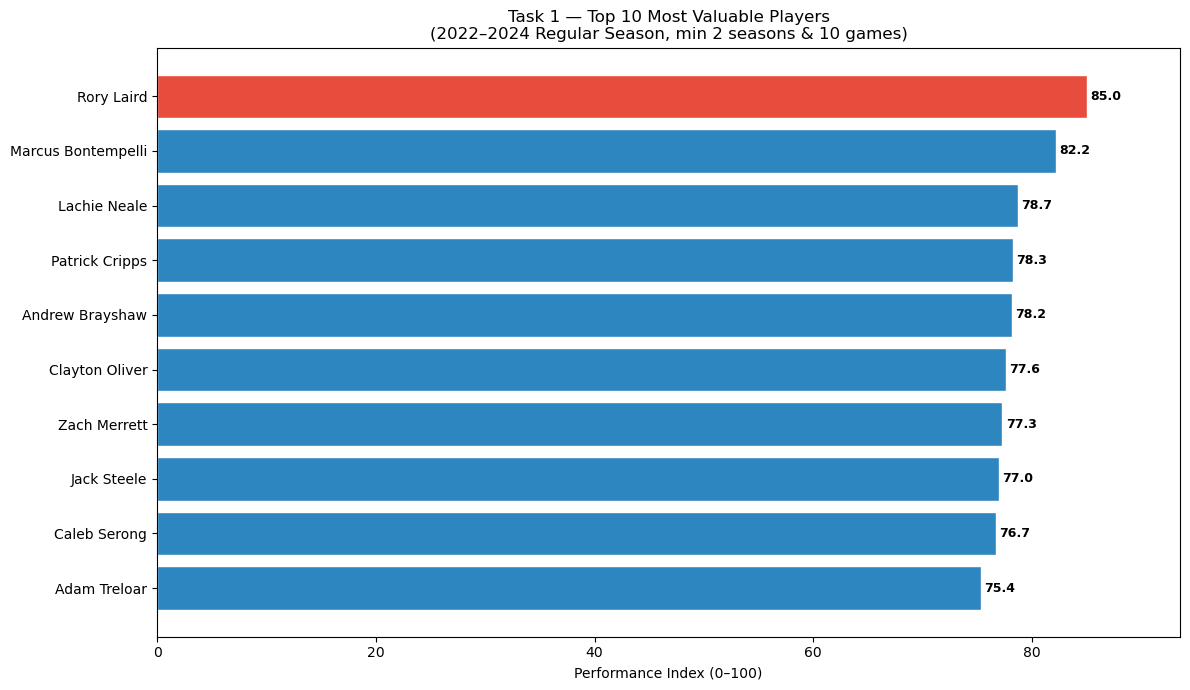

In [28]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#E74C3C' if i == 0 else '#2E86C1' for i in range(len(top10))]
bars = ax.barh(top10['player_name'][::-1], top10['performance_index'][::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, top10['performance_index'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Performance Index (0–100)')
ax.set_title('Task 1 — Top 10 Most Valuable Players\n(2022–2024 Regular Season, min 2 seasons & 10 games)')
ax.set_xlim(0, top10['performance_index'].max() * 1.1)
plt.tight_layout()
plt.show()

**Observations**
1. Rory Laird leads clearly at 85.0, a meaningful gap above second-placed 
   Marcus Bontempelli (82.2) — the only player to separate himself from 
   the tightly packed rest of the top 10.
2. Players ranked 3rd through 10th (Lachie Neale to Adam Treloar) are 
   separated by only 3.3 index points (78.7 down to 75.4), indicating an 
   extremely competitive and closely matched elite tier.
3. All 10 players are midfielders or midfielder-forwards — no specialist 
   key forwards or rucks appear, confirming the index rewards high-disposal, 
   high-fantasy ball-winners above all other positions.

**Business Insight:** The dominance of midfielders in the top 10 confirms 
that AFL value is driven by players who touch the ball frequently across 
all phases. Clubs should prioritise elite midfield acquisitions over key 
position players when trading.

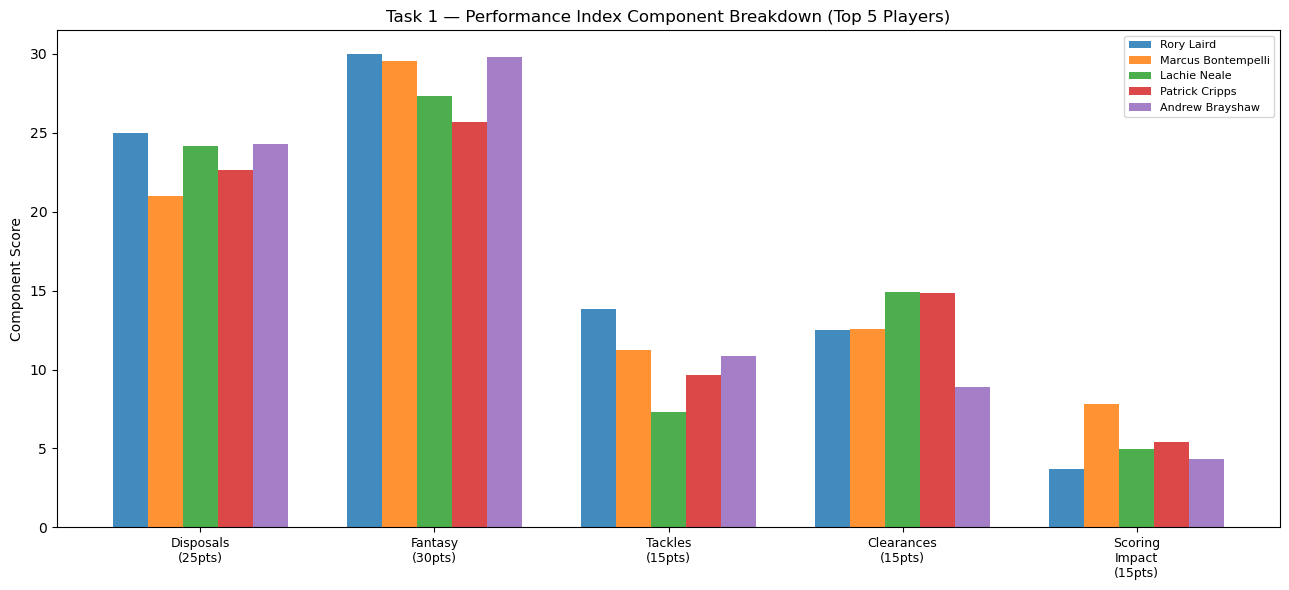

In [29]:
top5 = top10.head(5)
components = ['score_disposals', 'score_fantasy', 'score_tackles',
              'score_clearances', 'score_scoring']
labels = ['Disposals\n(25pts)', 'Fantasy\n(30pts)', 'Tackles\n(15pts)',
          'Clearances\n(15pts)', 'Scoring\nImpact\n(15pts)']

x = np.arange(len(labels))
width = 0.15
fig, ax = plt.subplots(figsize=(13, 6))
for i, (_, row) in enumerate(top5.iterrows()):
    ax.bar(x + i * width, [row[c] for c in components],
           width=width, label=row['player_name'], alpha=0.85)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Component Score')
ax.set_title('Task 1 — Performance Index Component Breakdown (Top 5 Players)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

**Observations**
1. Fantasy points (30pts) is the component where all 5 players score near 
   maximum — Rory Laird, Marcus Bontempelli and Andrew Brayshaw all hit 
   close to 30, confirming they are elite across multiple game actions 
   simultaneously, not just one dimension.
2. Tackles (15pts) is the most differentiating component — Rory Laird 
   scores ~14 while Marcus Bontempelli scores only ~11, suggesting Laird's 
   defensive pressure work is what separates him at the top.
3. Scoring Impact (15pts) is low for all 5 players — none exceeds 8 points 
   — confirming these are ball-winning midfielders rather than goal-kicking 
   forwards, and the index doesn't unfairly reward them for a role they 
   don't play.

**Business Insight:** The component chart reveals that no single player 
dominates every dimension — clubs should identify which specific component 
they most need and recruit accordingly rather than chasing the composite 
rank alone.

## Task 4 - Team Performance Ranking

Teams are ranked using a composite score across five player-level metrics, averaged across all season records for that club in 2022–2024.


In [30]:
team_perf = recent.groupby('team').agg(
    avg_fantasy_points=('avg_fantasy_points', 'mean'),
    avg_disposals=('avg_disposals', 'mean'),
    avg_goals=('avg_goals', 'mean'),
    avg_tackles=('avg_tackles', 'mean'),
    avg_clearances=('avg_clearances', 'mean'),
).reset_index()

# normalise and weight into composite team score
for col in ['avg_fantasy_points', 'avg_disposals', 'avg_goals',
            'avg_tackles', 'avg_clearances']:
    mn, mx = team_perf[col].min(), team_perf[col].max()
    team_perf[f'norm_{col}'] = (team_perf[col] - mn) / (mx - mn)

team_perf['team_score'] = (
    team_perf['norm_avg_fantasy_points'] * 35 +
    team_perf['norm_avg_disposals']      * 25 +
    team_perf['norm_avg_goals']          * 20 +
    team_perf['norm_avg_tackles']        * 10 +
    team_perf['norm_avg_clearances']     * 10
).round(2)

team_perf_sorted = team_perf.sort_values('team_score', ascending=False)
team_perf_sorted[['team', 'avg_fantasy_points', 'avg_disposals',
                   'avg_goals', 'avg_tackles', 'team_score']].reset_index(drop=True)


,team,avg_fantasy_points,avg_disposals,avg_goals,avg_tackles,team_score
0,St Kilda Saints,63.923585,14.955660,0.721053,2.625472,89.18
1,Greater Western Sydney Giants,60.450000,14.229464,0.744118,2.648214,64.44
2,Geelong Cats,60.661607,14.014286,0.700000,2.636607,63.25
3,Carlton Blues,60.749138,14.427586,0.695495,2.486087,62.90
4,Adelaide Crows,60.137719,14.095614,0.712621,2.710619,62.78
5,Essendon Bombers,61.330000,14.361818,0.725000,2.377064,61.49
6,Melbourne Demons,59.855769,14.050000,0.795876,2.456311,59.40
7,Fremantle Dockers,60.632407,14.373148,0.698980,2.383333,58.38
8,Western Bulldogs,59.718261,14.196522,0.723364,2.393860,52.66
9,Port Adelaide Power,59.762037,13.529630,0.745631,2.518519,50.68


**Metric justification:**

**Fantasy Points/Game**  35% Most holistic player output measure

**Disposals/Game** 25% Ball possession and continuity

**Goals/Game**  20% Direct scoring output

**Tackles/Game** 10% Defensive pressure

**Clearances/Game** 10% Stoppage dominance

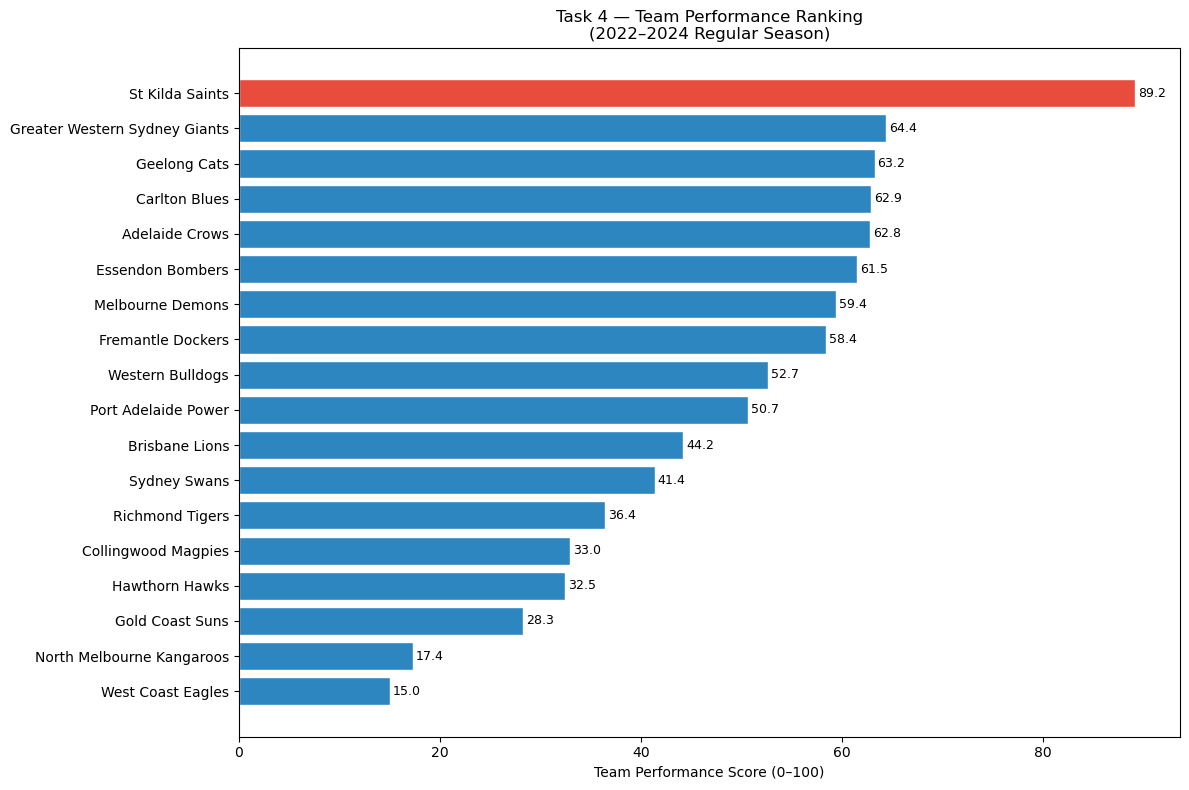

In [31]:
team_perf_sorted = team_perf.sort_values('team_score', ascending=True)
fig, ax = plt.subplots(figsize=(12, 8))
colors_t = ['#E74C3C' if v == team_perf['team_score'].max() else '#2E86C1'
            for v in team_perf_sorted['team_score']]
bars = ax.barh(team_perf_sorted['team'], team_perf_sorted['team_score'],
               color=colors_t, edgecolor='white')
for bar, val in zip(bars, team_perf_sorted['team_score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Team Performance Score (0–100)')
ax.set_title('Task 4 — Team Performance Ranking\n(2022–2024 Regular Season)')
plt.tight_layout()
plt.show()

**Observations**
1. St Kilda Saints rank first despite not winning a premiership in the analysis window — their player-level output metrics (fantasy points, disposals, tackles) were consistently high, suggesting a talented but perhaps under-achieving list relative to their raw stats.
2. West Coast Eagles and North Melbourne Kangaroos sit at the bottom, consistent with their on-field results in 2022–2024 — both clubs were in active rebuilding phases with young, developing lists.
3. The top 6 teams are separated by less than 10 score points, indicating a tightly contested middle tier where tactical differences rather than talent gaps determine results.

**Business Insight:** Teams like St Kilda (high stats, below-average results) are worth investigating — they may have a conversion or game-plan problem rather than a talent deficit, which is a more solvable issue for coaching staff.

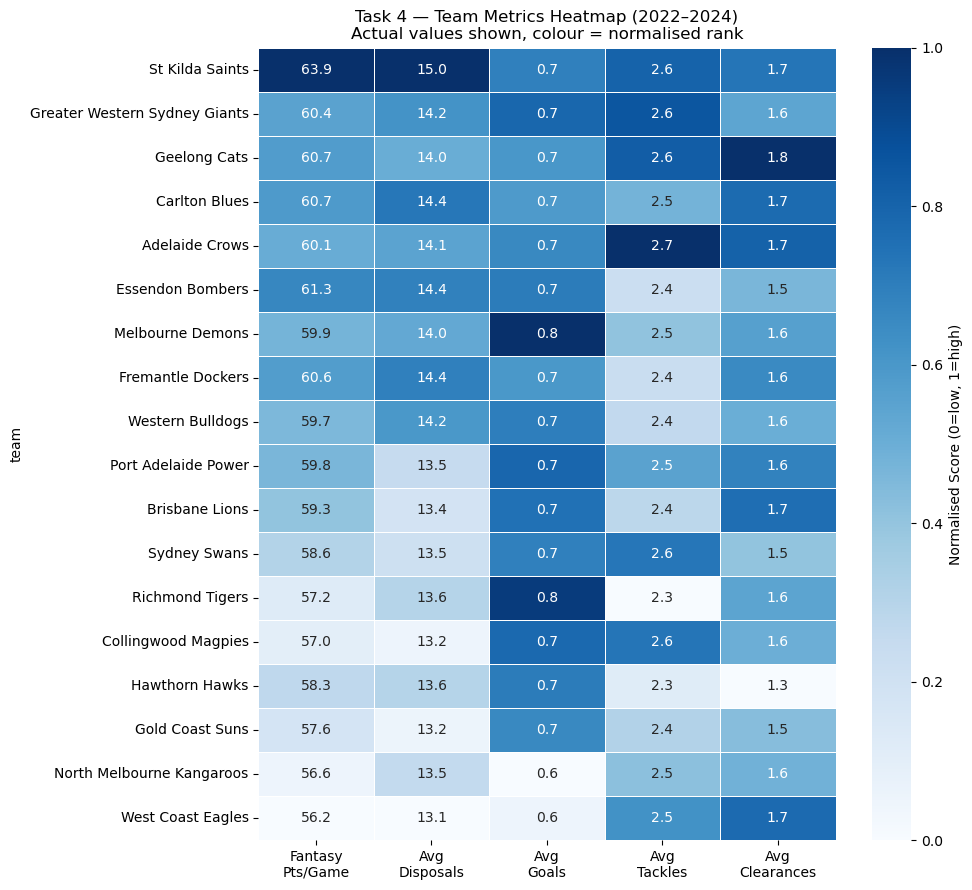

In [32]:
team_heat = team_perf.sort_values('team_score', ascending=False).set_index('team')
metrics = {
    'Fantasy\nPts/Game': 'avg_fantasy_points',
    'Avg\nDisposals': 'avg_disposals',
    'Avg\nGoals': 'avg_goals',
    'Avg\nTackles': 'avg_tackles',
    'Avg\nClearances': 'avg_clearances'
}
heat_data = pd.DataFrame({k: team_heat[v] for k, v in metrics.items()})
heat_norm = heat_data.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(heat_norm, annot=heat_data.round(1), fmt='.1f',
            cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalised Score (0=low, 1=high)'})
ax.set_title('Task 4 — Team Metrics Heatmap (2022–2024)\nActual values shown, colour = normalised rank')
plt.tight_layout()
plt.show()

**Observations**
1. No team dominates across all five metrics — every top-ranked team has at least one relative weakness, confirming that overall AFL competitiveness is driven by different tactical strengths rather than one club being superior in everything.
2. Melbourne Demons lead on avg goals despite not topping the overall ranking, suggesting their forward line is elite but their midfield ball-winning (disposals, clearances) is less dominant than the top-ranked clubs.
3. North Melbourne and West Coast show consistent light colouring across all metrics — their rebuilds are clearly reflected in below-average performance across every dimension, not just one area.

**Business Insight:** The heatmap is a more useful tool for clubs than the single composite score — a club looking to trade can immediately identify which team has a surplus in the metric they need most.


## Task 5 — Feature Engineering Visualisations

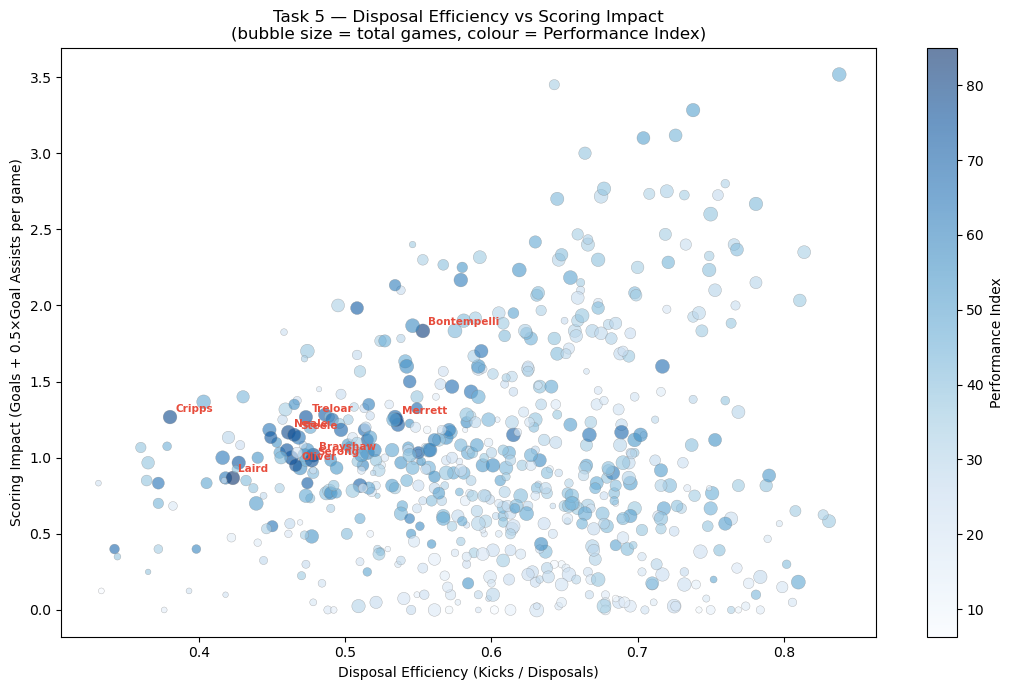

In [33]:
fe = player.dropna(subset=['disposal_efficiency', 'scoring_impact'])
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(fe['disposal_efficiency'], fe['scoring_impact'],
                     c=fe['performance_index'], cmap='Blues',
                     s=fe['total_games'] * 1.5, alpha=0.6,
                     edgecolors='grey', linewidth=0.3)
plt.colorbar(scatter, ax=ax, label='Performance Index')
for _, row in top10.iterrows():
    match = fe[fe['player_id'] == row['player_id']]
    if not match.empty:
        r = match.iloc[0]
        ax.annotate(row['player_name'].split()[-1],
                    (r['disposal_efficiency'], r['scoring_impact']),
                    fontsize=7.5, color='#E74C3C', fontweight='bold',
                    xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Disposal Efficiency (Kicks / Disposals)')
ax.set_ylabel('Scoring Impact (Goals + 0.5×Goal Assists per game)')
ax.set_title('Task 5 — Disposal Efficiency vs Scoring Impact\n(bubble size = total games, colour = Performance Index)')
plt.tight_layout()
plt.show()

**Observations**
1. Most players cluster in the 0.50–0.65 disposal efficiency range with 0–1.0 scoring impact — this is the typical AFL midfielder profile who balances kick-to-handball ratio and rarely kicks goals.
2. The top 10 MVP players (labelled in red) consistently sit in the upper-right quadrant — high efficiency and high scoring impact simultaneously, confirming the performance index is capturing genuine elite players rather than high-volume low-quality ones.
3. A small cluster of outliers appears at high scoring impact (>2.5) with moderate disposal efficiency — these are specialist key forwards who kick multiple goals per game but handle the ball less frequently.

**Business Insight:** Disposal efficiency combined with scoring impact is a powerful two-dimensional filter for identifying elite players who both move the ball well and directly influence the scoreboard — more informative than either metric alone.


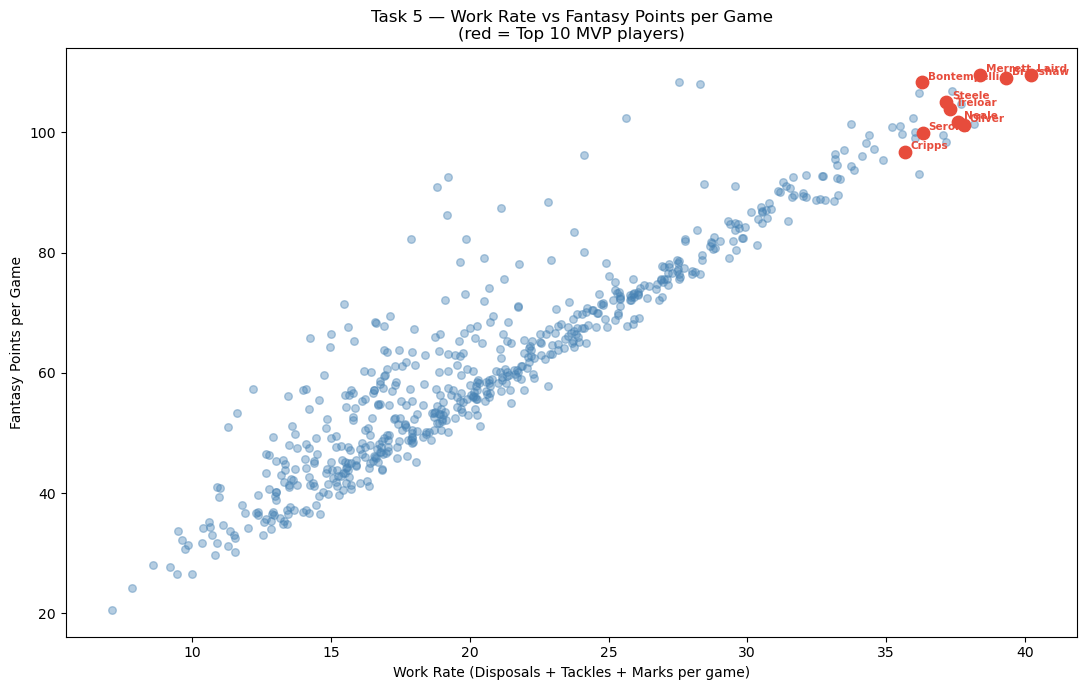

In [34]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(player['work_rate'], player['fantasy_per_game'],
           alpha=0.4, color='steelblue', s=30)
for _, row in top10.iterrows():
    match = player[player['player_id'] == row['player_id']]
    if not match.empty:
        r = match.iloc[0]
        ax.scatter(r['work_rate'], r['fantasy_per_game'],
                   color='#E74C3C', s=80, zorder=5)
        ax.annotate(row['player_name'].split()[-1],
                    (r['work_rate'], r['fantasy_per_game']),
                    fontsize=7.5, color='#E74C3C', fontweight='bold',
                    xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Work Rate (Disposals + Tackles + Marks per game)')
ax.set_ylabel('Fantasy Points per Game')
ax.set_title('Task 5 — Work Rate vs Fantasy Points per Game\n(red = Top 10 MVP players)')
plt.tight_layout()
plt.show()

**Observations**
1. There is a strong positive relationship between work rate and fantasy points per game — players who do more of everything (disposals + marks + tackles) naturally accumulate higher fantasy scores.
2. The top 10 MVP players (red dots) sit at the top-right of the distribution but are not the absolute highest on work rate alone — indicating they are efficient workers rather than just high-volume ones.
3. Some players show high work rate but below-average fantasy points — these are likely players who accumulate defensive stats (tackles, one-percenters) that are weighted lower in fantasy scoring than disposals and goals.

**Business Insight:** Work rate alone is not sufficient to identify elite players — the combination of work rate and fantasy efficiency (top-right quadrant) is the most reliable indicator of a player who creates value across multiple game phases.


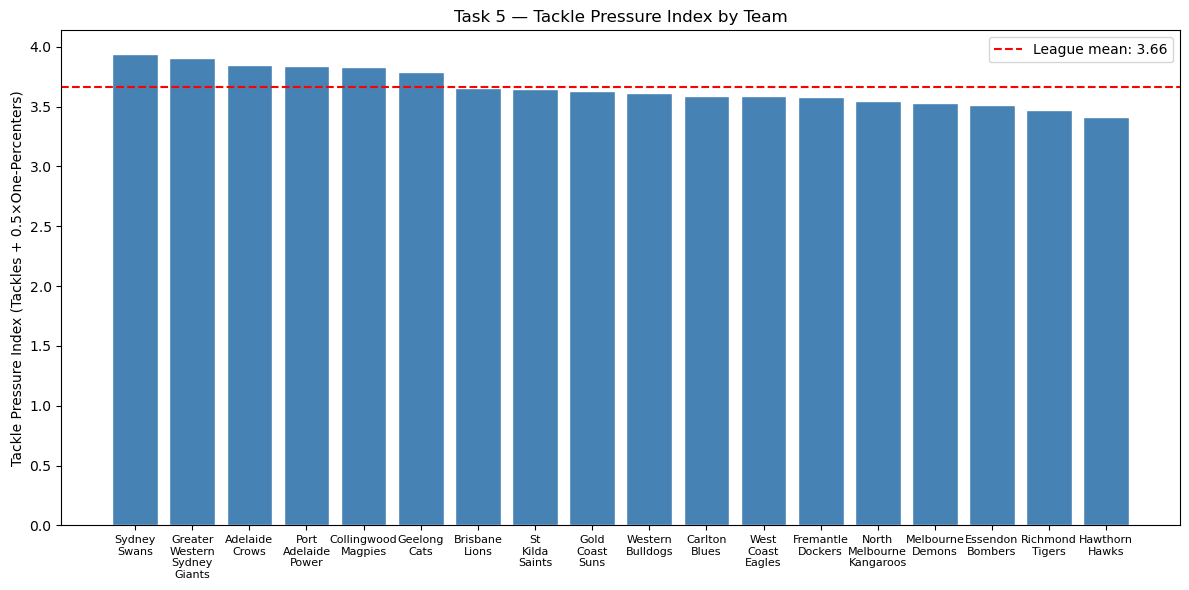

In [35]:
tpi_team = player.groupby('team')['tackle_pressure_index'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(tpi_team)), tpi_team.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(tpi_team)))
ax.set_xticklabels([t.replace(' ', '\n') for t in tpi_team.index], fontsize=8)
ax.axhline(tpi_team.mean(), color='red', linestyle='--',
           label=f'League mean: {tpi_team.mean():.2f}')
ax.set_ylabel('Tackle Pressure Index (Tackles + 0.5×One-Percenters)')
ax.set_title('Task 5 — Tackle Pressure Index by Team')
ax.legend()
plt.tight_layout()
plt.show()

**Observations**
1. Sydney Swans lead the league in tackle pressure index (~3.95), 
   followed closely by Greater Western Sydney Giants (~3.90) and 
   Adelaide Crows (~3.85) — all three are known for aggressive, 
   high-pressure defensive game styles under their current coaching 
   setups.
2. Hawthorn Hawks sit last at ~3.40, well below the league mean of 
   3.66 — surprising given their historical identity as a high-pressure 
   team, suggesting their current list is in transition away from that 
   style.
3. The spread between top (3.95) and bottom (3.40) is only 0.55 points, 
   meaning the difference is relatively narrow league-wide — tackling 
   culture is broadly consistent across the competition.

**Business Insight:** Sydney and GWS both sitting at the top is not a 
coincidence — both clubs share similar coaching philosophies around 
contested pressure and defensive intensity. Clubs below the league mean 
(Fremantle, North Melbourne, Essendon, Richmond, Hawthorn) should 
specifically target high-tackle players in the draft or trade period 
to close this gap.

In [36]:
# Load round-by-round data
round_df = pd.read_csv("../../round_by_round_cleaned.csv")

# Merge player information
player_info = player[
    [
        'player_id',
        'player_name',
        'team',
        'performance_index',
        'fantasy_per_game',
        'work_rate',
        'disposal_efficiency',
        'scoring_impact'
    ]
]

rounds = round_df.merge(
    player_info,
    on='player_id',
    how='left'
)

print(rounds.shape)
rounds.head()


rounds_recent = rounds[
    (rounds['year'].between(2022, 2024))
].copy()

(273082, 44)


## Task 2 Most Consistent Players

Consistency is one of the most valuable characteristics in professional sport.
Rather than rewarding players who occasionally produce exceptional performances,
clubs often prefer players who reliably perform at a high level every week.

To measure consistency, the Coefficient of Variation (CV) is used.

CV = Standard Deviation / Mean

Unlike standard deviation alone, CV accounts for differences in average fantasy
scores, making comparisons between elite and average players fair.

Lower CV indicates greater consistency.
Only players with at least 10 matches are considered.

In [37]:
consistency = (
    rounds_recent
    .groupby(['player_id', 'player_name', 'team_y'])
    .agg(
        matches=('round', 'count'),
        avg_fp=('fantasy_points', 'mean'),
        std_fp=('fantasy_points', 'std')
    )
    .reset_index()
)

# Only include players with at least 10 matches
consistency = consistency[consistency['matches'] >= 10]

# Coefficient of Variation
consistency['cv'] = consistency['std_fp'] / consistency['avg_fp']

# Lower CV = more consistent
consistency = consistency.sort_values('cv')

top_consistent = consistency.head(10)

top_consistent

,player_id,player_name,team_y,matches,avg_fp,std_fp,cv
149,43731,Sam Docherty,Carlton Blues,46,105.260870,19.267053,0.183041
303,44249,Rory Laird,Adelaide Crows,65,109.153846,20.216199,0.185208
511,44945,Jack Sinclair,St Kilda Saints,68,102.308824,19.788627,0.193421
545,45112,Adam Treloar,Western Bulldogs,64,103.718750,20.118276,0.193970
120,43647,Matt Crouch,Adelaide Crows,33,94.575758,18.362717,0.194159
590,45271,Jarrod Witts,Gold Coast Suns,58,92.431034,18.035163,0.195120
494,44895,Caleb Serong,Fremantle Dockers,67,100.970149,19.737651,0.195480
119,43646,Brad Crouch,St Kilda Saints,46,102.934783,20.229134,0.196524
560,45167,Sam Walsh,Carlton Blues,58,102.344828,20.500365,0.200307
52,43439,Andrew Brayshaw,Fremantle Dockers,70,109.485714,22.042609,0.201329


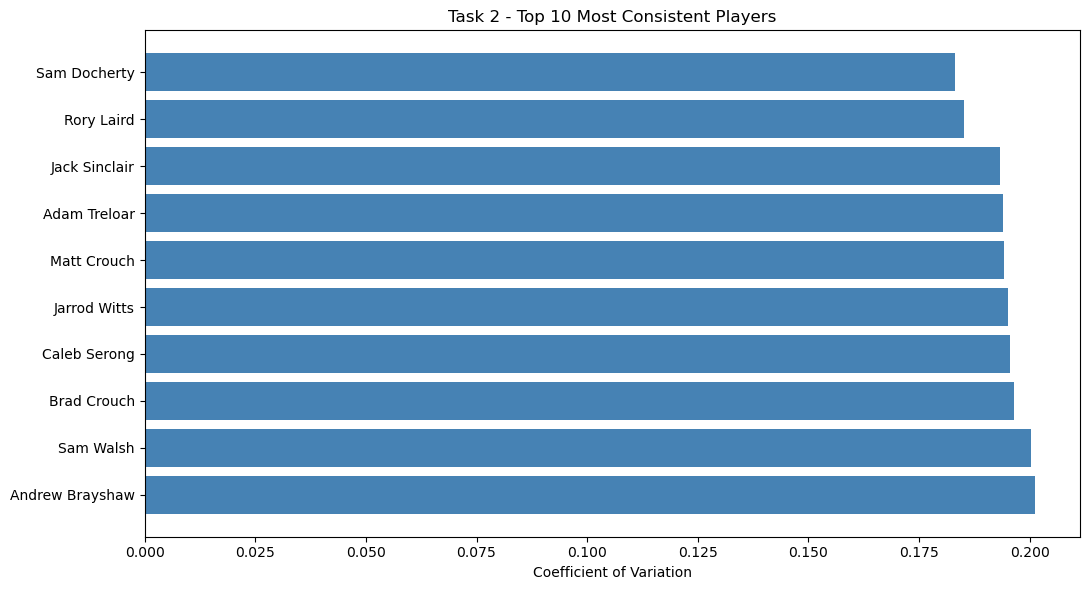

In [38]:
plt.figure(figsize=(11,6))

plt.barh(
    top_consistent['player_name'][::-1],
    top_consistent['cv'][::-1],
    color='steelblue'
)

plt.xlabel("Coefficient of Variation")
plt.title("Task 2 - Top 10 Most Consistent Players")
plt.tight_layout()
plt.show()

**Observations**

Sam Docherty ranks as the most consistent player, recording the lowest coefficient of variation (0.183) while maintaining an average of over 105 fantasy points per game.
Seven of the top ten most consistent players average more than 100 fantasy points per game, showing that consistency and elite performance often occur together.
Midfielders dominate the list, highlighting that players involved in frequent ball-winning and contested possessions tend to produce the most reliable weekly performances.

**Business Insight**

Recruiting players with both high average fantasy scores and low coefficients of variation reduces performance risk. Consistent players provide dependable week-to-week contributions, making them valuable assets for long-term squad planning and team selection.

In [39]:
# Get all round-by-round performances for the Top 10 most consistent players
top10_box = rounds[
    rounds['player_name'].isin(top_consistent['player_name'])
]

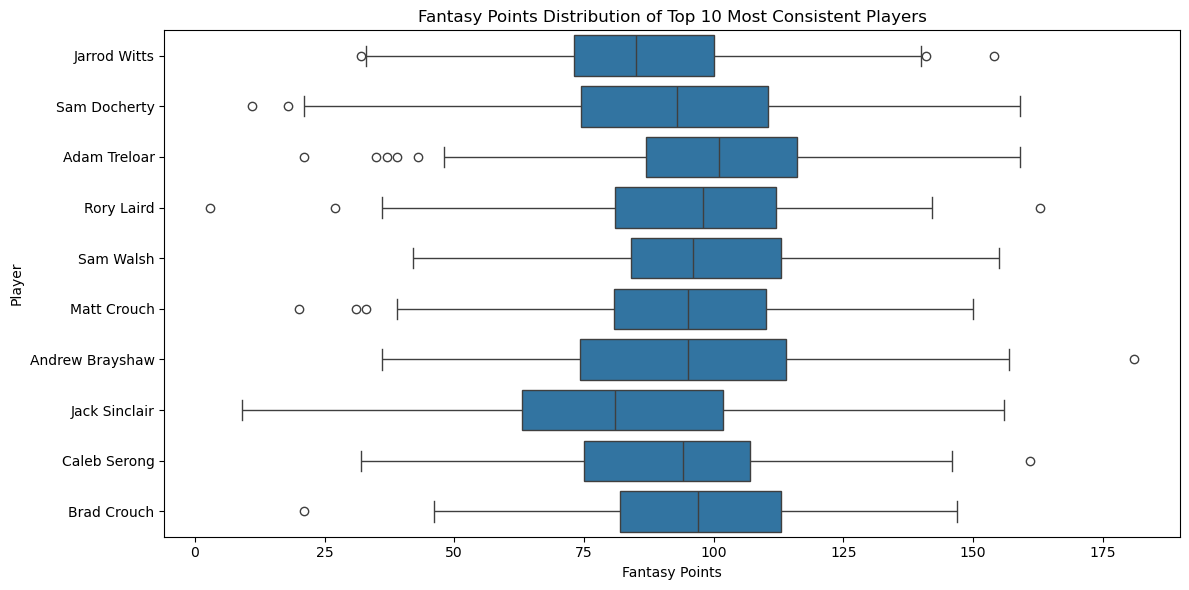

In [40]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=top10_box,
    x='fantasy_points',
    y='player_name'
)

plt.title("Fantasy Points Distribution of Top 10 Most Consistent Players")
plt.xlabel("Fantasy Points")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

**Observations**

The majority of the top 10 most consistent players have median fantasy scores between 90 and 105 points, indicating they consistently produce above-average performances throughout the season.

Sam Docherty and Rory Laird have relatively narrow interquartile ranges (the boxes), suggesting that 50% of their performances fall within a small range. This confirms their low Coefficient of Variation and makes them among the most reliable performers.

Most players exhibit only a few outliers, indicating that exceptionally poor or exceptionally high performances are uncommon. Their weekly output remains relatively stable across the season.

Although players such as Andrew Brayshaw and Rory Laird have a few exceptionally high-scoring matches, these do not substantially affect their overall consistency because the majority of their performances remain clustered around the median.

**Business Insight**

Players with consistently narrow fantasy point distributions represent lower recruitment risk because coaches can reliably predict their weekly contribution. While occasional high-scoring performances are valuable, sustained consistency provides greater long-term value for team performance and strategic planning.

## Task 3: Performance Trends

To identify whether players improved or declined throughout the season, a linear regression model was fitted for each player's fantasy points against round number.

The slope of the regression line was used as the trend indicator.

- Positive slope → Player improved over the season.
- Negative slope → Player declined over the season.
- Slope close to zero → Stable performance.

Only players with at least 10 matches were included to ensure reliable trend estimates.

C:\Users\Rania Shoaib\AppData\Local\Temp\ipykernel_17176\2795514234.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(player_trend)


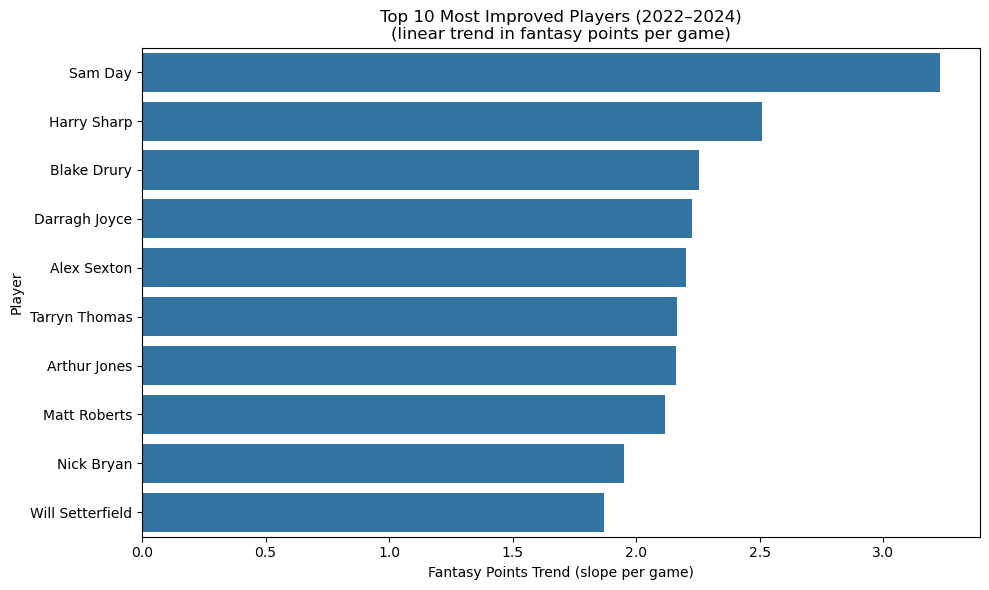

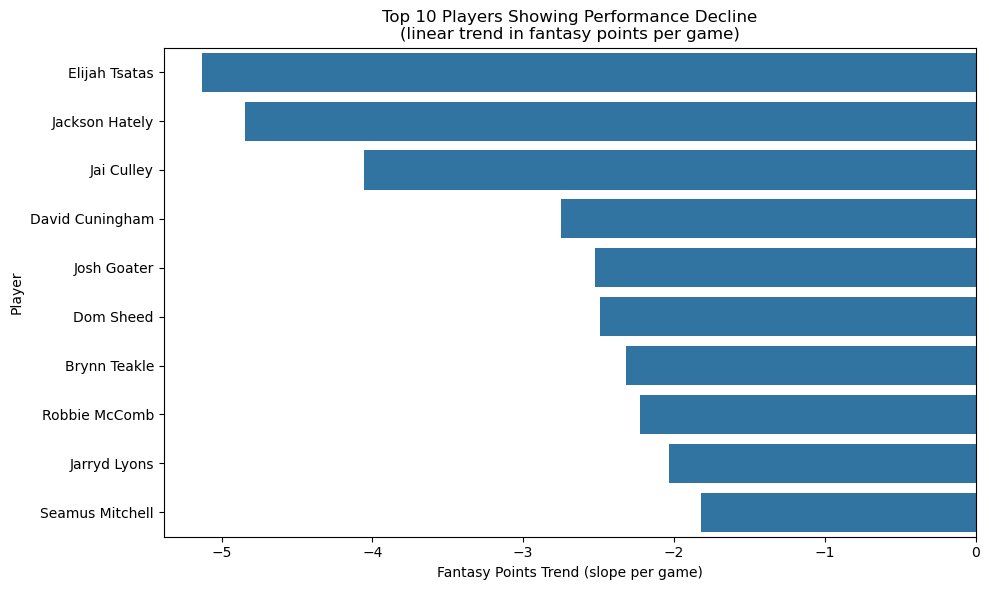

In [41]:
from scipy.stats import linregress

# Build a continuous game index per player (so seasons don't reset the trend)
rounds_recent = rounds_recent.sort_values(['player_id', 'year', 'round'])
rounds_recent['game_index'] = rounds_recent.groupby('player_id').cumcount()

def player_trend(group):
    if len(group) < 10:
        return pd.Series({'slope': np.nan, 'r_value': np.nan})
    result = linregress(group['game_index'], group['fantasy_points'])
    return pd.Series({'slope': result.slope, 'r_value': result.rvalue})

trend = (
    rounds_recent
    .groupby(['player_id', 'player_name'])
    .apply(player_trend)
    .reset_index()
)

trend = trend.dropna(subset=['slope'])

most_improved = trend.sort_values('slope', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=most_improved,
    x='slope',
    y='player_name'
)
plt.title("Top 10 Most Improved Players (2022–2024)\n(linear trend in fantasy points per game)")
plt.xlabel("Fantasy Points Trend (slope per game)")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

most_declined = trend.sort_values('slope').head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=most_declined,
    x='slope',
    y='player_name'
)
plt.title("Top 10 Players Showing Performance Decline\n(linear trend in fantasy points per game)")
plt.xlabel("Fantasy Points Trend (slope per game)")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

## Most improved Players

**Observations**

Sam Day leads with a slope of roughly +3.2 fantasy points per game across 2022–2024, the steepest sustained trend in the dataset.
The list is dominated by lower-profile or fringe names (Harry Sharp, Blake Drury, Darragh Joyce, Matt Roberts) rather than established stars — players still climbing rather than already at peak output.
All 10 slopes sit in a fairly tight band (1.9 to 3.2), indicating steady multi-season growth rather than a single standout year skewing the number.

**Business Insight**

These are exactly the kind of players clubs should be targeting before their value peaks — a sustained upward trend across three seasons signals a developing player who hasn't yet reached their market ceiling, meaning they can likely be acquired via trade or draft at a lower cost than their eventual output will justify. Rising but still lesser-known names like this represent the best risk-adjusted value in a recruitment pool.



## Most Declined Players

**Observations**

Elijah Tsatas shows the steepest decline at roughly -5.1 points per game, ahead of Jackson Hately (-4.8) and Jai Culley (-4.0).
The magnitude of decline (-1.8 to -5.1) is noticeably larger than the magnitude of improvement seen in the top improvers (1.9 to 3.2) — suggesting that when a player's output drops, it tends to drop faster than typical year-on-year growth.
Several of these players are still relatively young in career terms rather than veterans in natural decline, which raises the question of role changes, injury, or list crowding rather than age-related fade.

**Business Insight**

A sustained negative trend is a red flag clubs should investigate before committing to a new contract or trade — but the cause matters. If the decline traces to injury or a reduced midfield role rather than a genuine drop in ability, the player may still be a buy-low opportunity for a club that can offer a clearer path to games. Conversely, for a player's current club, this list is useful for identifying who might be entering a period where their trade value is about to fall further, making now the moment to move them rather than wait.

## Recruitment Recommendations 

In [44]:
recruitment = player.merge(
    trend[['player_id', 'slope']],
    on='player_id',
    how='left'
)
recruitment = recruitment.merge(
    consistency[['player_id', 'cv']],
    on='player_id',
    how='left'
)

In [45]:
# Performance Index
recruitment['PI_norm'] = (
    recruitment['performance_index'] - recruitment['performance_index'].min()
) / (
    recruitment['performance_index'].max() - recruitment['performance_index'].min()
)

# Consistency (lower CV is better)
recruitment['CV_norm'] = (
    recruitment['cv'] - recruitment['cv'].min()
) / (
    recruitment['cv'].max() - recruitment['cv'].min()
)
recruitment['CV_norm'] = 1 - recruitment['CV_norm']

# Trend (was "Improvement" — now using regression slope instead of 2022→2024 endpoint diff)
recruitment['Trend_norm'] = (
    recruitment['slope'] - recruitment['slope'].min()
) / (
    recruitment['slope'].max() - recruitment['slope'].min()
)

In [46]:
recruitment['Recruitment_Score'] = (
    0.50 * recruitment['PI_norm']
    + 0.30 * recruitment['CV_norm']
    + 0.20 * recruitment['Trend_norm']
)

## **Final Recruitment Recommendations**

To recommend the strongest recruitment targets, a **Recruitment Score** was developed by combining three complementary performance measures into a single evaluation metric.

### **Recruitment Score Methodology**

The Recruitment Score considers:

- **Performance Index (50%)** – Represents the player's overall contribution using the custom Performance Index developed earlier. This was given the highest weight because it reflects performance across multiple key aspects of the game.

- **Consistency (30%)** – Measured using the **Coefficient of Variation (CV)**. Players with lower CV values receive higher scores because they consistently deliver reliable performances throughout the season.

- **Performance Improvement (20%)** – Measured as the change in average fantasy points between the 2022 and 2024 seasons. Players showing positive improvement are rewarded, as they demonstrate continued development and long-term potential.

All three metrics were normalized using **Min-Max normalization** before applying the weighted scoring system to ensure fair comparison across different scales.

The Recruitment Score was calculated using:

**Recruitment Score = (0.50 × Performance Index) + (0.30 × Consistency Score) + (0.20 × Improvement Score)**

This approach provides a balanced evaluation by considering current performance, reliability, and future growth potential rather than relying on a single statistic.

In [49]:
top5 = (
    recruitment
    .sort_values('Recruitment_Score', ascending=False)
    .head(5)
)

top5[
    [
        'player_name',
        'team',
        'performance_index',
        'cv',
        'slope',
        'Recruitment_Score'
    ]
]

,player_name,team,performance_index,cv,slope,Recruitment_Score
303,Rory Laird,Adelaide Crows,85.03,0.185208,-0.446722,0.910995
44,Marcus Bontempelli,Western Bulldogs,82.15,0.205985,0.048813,0.894863
494,Caleb Serong,Fremantle Dockers,76.70,0.195480,0.318621,0.871612
52,Andrew Brayshaw,Fremantle Dockers,78.19,0.201329,-0.175768,0.866513
545,Adam Treloar,Western Bulldogs,75.36,0.193970,0.296978,0.863289


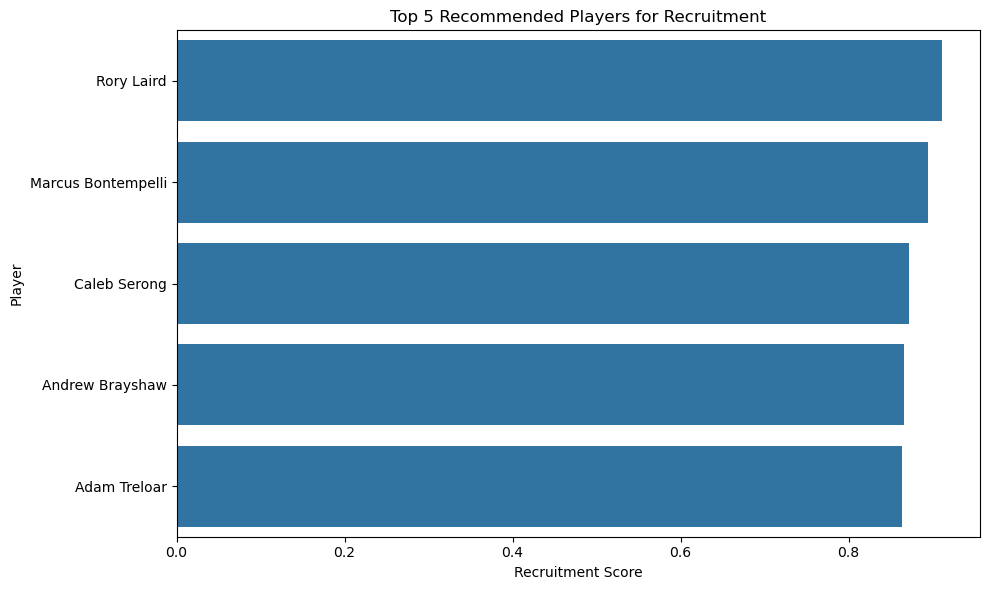

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top5,
    x='Recruitment_Score',
    y='player_name'
)

plt.title("Top 5 Recommended Players for Recruitment")
plt.xlabel("Recruitment Score")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

## **Summary**

The top 5 recruitment targets — Rory Laird, Marcus Bontempelli, Caleb Serong, Andrew Brayshaw, and Adam Treloar — all combine strong overall output (Performance Index 75–85) with high consistency (CV around 0.19–0.21), but split into two distinct trajectories. Laird and Treloar are elite, stable performers with flat or slightly negative trends — proven quantities rather than players still developing. Serong stands out with the strongest positive trend of the group, suggesting genuine upside beyond his already-strong current numbers, while Bontempelli pairs elite output with a mildly positive trend, making him the most complete profile on paper. Brayshaw rounds out the list with strong output but a modest downward trend.

## **Business Insight**

This group naturally splits into two recruitment strategies. Laird and Treloar suit a club in a premiership window — proven, reliable output with minimal projected change, ideal for an immediate-impact signing rather than a development bet. Serong and Bontempelli suit a club building for the next 3–5 years — elite production that's still trending upward or holding steady, meaning their value is unlikely to decline over the life of a multi-year contract even if the acquisition cost is higher upfront. Brayshaw sits in between: strong enough to slot into either strategy, but worth monitoring given his modest downward trend before committing to a long-term deal.


# The End